Text(-0.25838384992852226, 0.686229650377131, '$(x_i,y_i)$')

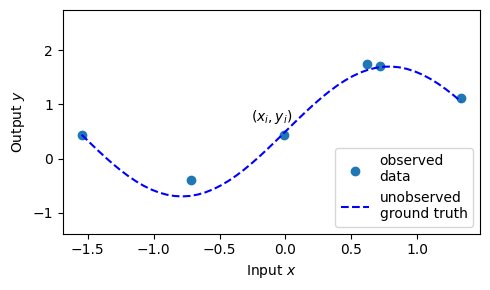

In [1]:
import numpy as np
import matplotlib.pyplot as plt
np.random.seed(10)

m = 6
x = np.random.randn(m)
noise = 0.25 * np.random.randn(m)
y = 1.2*(np.sin(2*x)) + 0.5 + noise

X_tilde = np.vstack([ x**p for p in range(m)]).T
plt.figure(figsize=(5,3))
plt.scatter(x,y, label='observed\ndata')

x_grid = np.linspace(np.min(x),np.max(x))
plt.plot(x_grid, 1.2*(np.sin(2*x_grid)) + 0.5, "b--", label='unobserved\nground truth')

plt.ylim(np.min(y)-1, np.max(y)+1)
plt.xlabel(r'Input $x$')
plt.ylabel(r'Output $y$')
plt.legend(loc='lower right')
plt.tight_layout()
j = 3
plt.text(x[j]-0.25, y[j]+0.25, r'$(x_i,y_i)$')


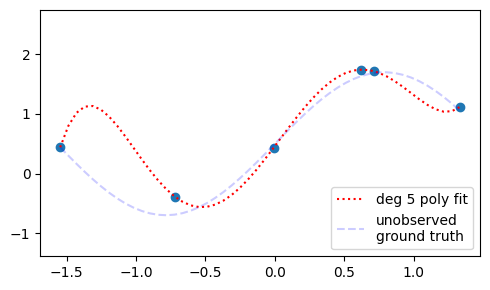

In [2]:
# X_tilde @ w = y ?
X_tilde_inv = np.linalg.inv(X_tilde)
w = X_tilde_inv @ y

w = np.linalg.solve(X_tilde, y)

x_grid = np.linspace(np.min(x),np.max(x))
X_tilde_grid = np.vstack([x_grid**p for p in range(m)]).T
y_grid = X_tilde_grid@w

plt.figure(figsize=(5,3))

plt.plot(x_grid, y_grid, "r:", label='deg 5 poly fit')
plt.scatter(x,y)
plt.ylim(np.min(y)-1, np.max(y)+1)
plt.plot(x_grid, 1.2*(np.sin(2*x_grid)) + 0.5, "b--", label='unobserved\nground truth', alpha=0.2)
plt.legend(loc='lower right')

plt.tight_layout()

In [3]:
assert( np.sum( np.square(y - X_tilde @ w)) < 1e-10 )

In [4]:
# THIS SHOULD WORK
X_tilde = np.vstack([ x**p for p in range(2)]).T
# find min || X_tilde @ w - y ||^2 where w is a 2 dimensional vector
X_tilde_inv = np.linalg.pinv(X_tilde)
w = X_tilde_inv @ y

np.float64(1.8040541379552868)

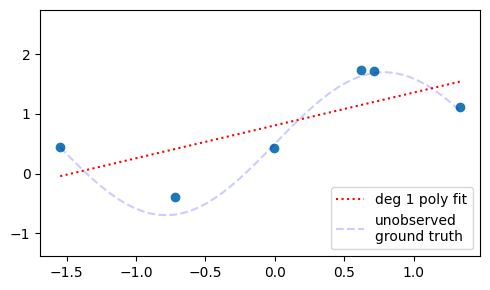

In [5]:
x_grid = np.linspace(np.min(x),np.max(x))
X_tilde_grid = np.vstack([x_grid**p for p in range(2)]).T
y_grid = X_tilde_grid@w

plt.figure(figsize=(5,3))
plt.plot(x_grid, y_grid, "r:", label='deg 1 poly fit')
plt.scatter(x,y)
# plt.plot(x_grid, y_grid)
plt.ylim(np.min(y)-1, np.max(y)+1)

plt.plot(x_grid, 1.2*(np.sin(2*x_grid)) + 0.5, "b--", label='unobserved\nground truth', alpha=0.2)
plt.legend(loc='lower right')

plt.tight_layout()
np.sum( np.square(y - X_tilde @ w))

In [6]:
# THIS SHOULD WORK
d = 4
X_tilde = np.vstack([ x**p for p in range(d)]).T
# find min || X_tilde @ w - y ||^2 where w is a 2 dimensional vector
X_tilde_inv = np.linalg.pinv(X_tilde)
w = X_tilde_inv @ y

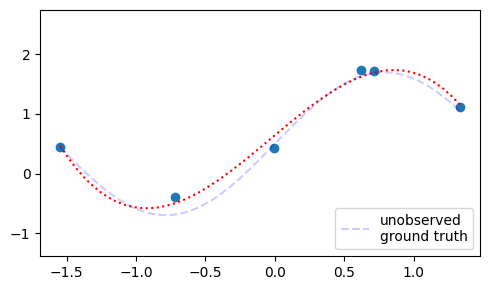

In [7]:
x_grid = np.linspace(np.min(x),np.max(x))
X_tilde_grid = np.vstack([x_grid**p for p in range(d)]).T
y_grid = X_tilde_grid@w
plt.figure(figsize=(5,3))
plt.plot(x_grid, y_grid, "r:")
plt.scatter(x,y)
# plt.plot(x_grid, y_grid)
plt.ylim(np.min(y)-1, np.max(y)+1)
plt.plot(x_grid, 1.2*(np.sin(2*x_grid)) + 0.5, "b--", label='unobserved\nground truth', alpha=0.2)
plt.legend(loc='lower right')

plt.tight_layout()

# Exercise: compute training error versus degree

Text(0, 0.5, 'training error')

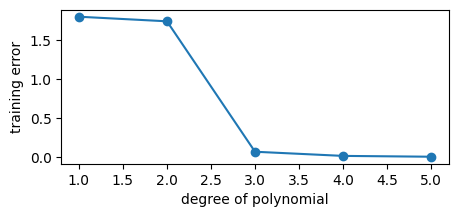

In [8]:
training_errors = []
degrees = range(1, 6)
for d in degrees:
    X_tilde = np.vstack([ x**p for p in range(d+1)]).T
    X_tilde_inv = np.linalg.pinv(X_tilde)
    w = X_tilde_inv @ y
   
    training_error = np.sum( np.square(y - X_tilde @ w))
    training_errors.append(training_error)

plt.figure(figsize=(5,2))
plt.plot(degrees, training_errors)
plt.scatter(degrees, training_errors)
plt.xlabel('degree of polynomial')
plt.ylabel('training error')  



# Generalization

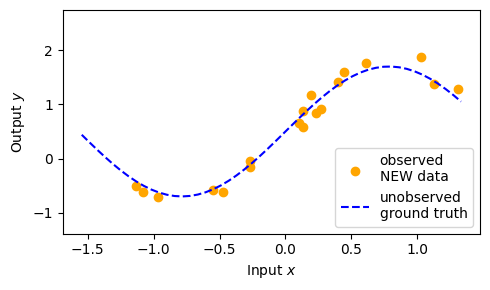

In [9]:
m_test = 25
x_test = np.random.randn(m_test)
# filter to within same range as original training data [...]

filter_these_points = ( x_test < np.max(x) )* (x_test > np.min(x))
x_test = x_test[filter_these_points]

noise = 0.25 * np.random.randn(len(x_test))
y_test = 1.2*(np.sin(2*x_test)) + 0.5 + noise

m = 6
X_test_tilde = np.vstack([ x_test**p for p in range(m)]).T
plt.figure(figsize=(5,3))
plt.scatter(x_test,y_test, color = 'orange', label='observed\nNEW data')

x_grid = np.linspace(np.min(x),np.max(x))
plt.plot(x_grid, 1.2*(np.sin(2*x_grid)) + 0.5, "b--", label='unobserved\nground truth')

plt.ylim(np.min(y)-1, np.max(y)+1)
plt.xlabel(r'Input $x$')
plt.ylabel(r'Output $y$')
plt.legend(loc='lower right')
plt.tight_layout()
j = 3



# Exercise 1: compute testing error versus degree

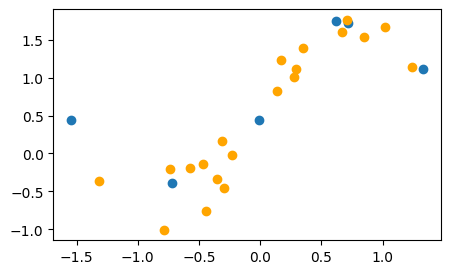

In [12]:
# generate more (25) test points as we did at the beginning
# copy this same loop for evaluating the training loss above, but with the fresh data
# filter out data points that are smaller than np.min(x)
# and also data points that are larger than np.max(x)


m = 25
x_test = np.random.randn(m)
noise = 0.25 * np.random.randn(m)
y_test = 1.2*(np.sin(2*x_test)) + 0.5 + noise

filter_these_points = ( x_test < np.max(x) )* (x_test > np.min(x))
x_test = x_test[filter_these_points]
y_test = y_test[filter_these_points]

plt.figure(figsize=(5,3))
plt.scatter(x,y, label='training')
plt.scatter(x_test, y_test, color='orange', label='test')

Text(0.5, 0, 'degree of polynomial')

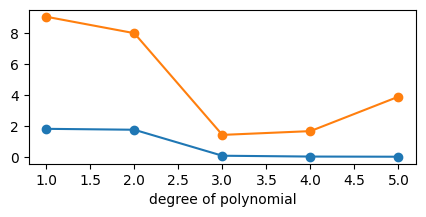

In [15]:
training_errors = []
testing_errors = []
degrees = range(1, 6)
d=5
for d in degrees:
    X_tilde = np.vstack([ x**p for p in range(d+1)]).T
    X_tilde_inv = np.linalg.pinv(X_tilde)
    w = X_tilde_inv @ y

    X_tilde_test = np.vstack([ x_test**p for p in range(d+1)]).T
    X_tilde_inv_test = np.linalg.pinv(X_tilde_test)
   
    training_error = np.sum( np.square(y - X_tilde @ w))
    training_errors.append(training_error)
    testing_error = np.sum( np.square(y_test - X_tilde_test @ w))
    testing_errors.append(testing_error)

plt.figure(figsize=(5,2))
plt.plot(degrees, training_errors, label='training error')
plt.plot(degrees, testing_errors, label='testing error')
plt.scatter(degrees, training_errors)
plt.scatter(degrees, testing_errors)
plt.xlabel('degree of polynomial')



(-1.389017438908459, 2.7442347007006385)

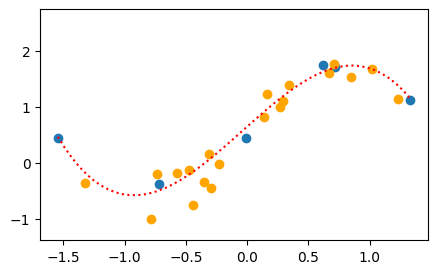

In [16]:
d =5
X_tilde = np.vstack([ x**p for p in range(d+1)]).T
X_tilde_inv = np.linalg.pinv(X_tilde)
w = X_tilde_inv @ y

plt.figure(figsize=(5,3))
plt.plot(x_grid, y_grid, "r:", label='deg 5 poly fit')
plt.scatter(x,y)
plt.scatter(x_test, y_test, color='orange', label='test')
plt.ylim(np.min(y)-1, np.max(y)+1)
